In [ ]:
import sys
from pathlib import Path

_root = Path.cwd().resolve()
if not (_root / "src").is_dir():
    _root = _root.parent
sys.path.insert(0, str(_root))

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from src.evaluate import (
    brier_score,
    log_loss_score,
    expected_calibration_error,
    compute_all_metrics,
    per_category_metrics,
)
from src.config import DATA_PROCESSED_DIR, POSTERIORS_DIR, FIGURES_DIR, PROJECT_ROOT

OUT_DIR = PROJECT_ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
Path(FIGURES_DIR).mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

df_test = pd.read_csv(Path(DATA_PROCESSED_DIR) / "markets_test.csv")
y_test = df_test["outcome"].values
with open(Path(POSTERIORS_DIR) / "all_predictions.pkl", "rb") as f:
    predictions = pickle.load(f)
categories = sorted(df_test["category_str"].unique().tolist())

In [2]:
metrics_df = compute_all_metrics(y_test, predictions)
metrics_df.to_csv(OUT_DIR / "metrics_summary.csv", index=False)

       Model  Brier Score  Log Loss    ECE  Brier Skill Score
    Isotonic       0.2346    0.6559 0.0565             0.0307
    Logistic       0.2350    0.6578 0.0580             0.0290
HBRM (Bayes)       0.2333    0.6627 0.0911             0.0363
  Raw Market       0.2403    0.6684 0.0929             0.0071


C:\Users\yatha\AppData\Local\Temp\ipykernel_8624\2058505604.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


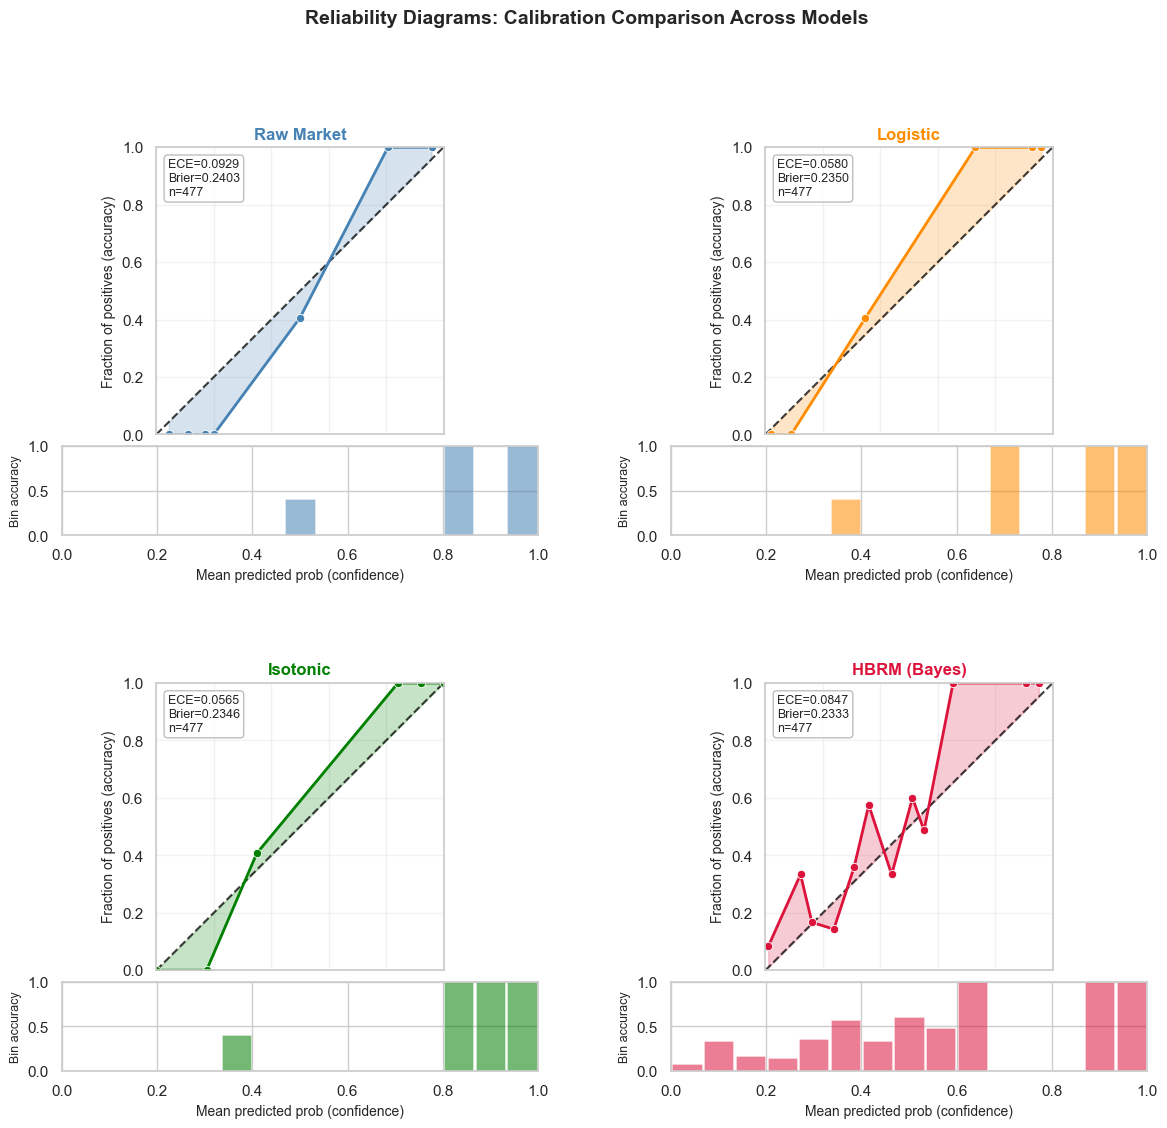

In [3]:
models_order = ["Raw Market", "Logistic", "Isotonic", "HBRM (Bayes)"]
colors = ["steelblue", "darkorange", "green", "crimson"]
n_bins_rel = 15

fig = plt.figure(figsize=(14, 12))
outer = fig.add_gridspec(2, 2, wspace=0.28, hspace=0.38)

for idx, (model, color) in enumerate(zip(models_order, colors)):
    row, col = idx // 2, idx % 2
    inner = outer[row, col].subgridspec(2, 1, height_ratios=[3.2, 1.0], hspace=0.06)
    ax_top = fig.add_subplot(inner[0])
    ax_bot = fig.add_subplot(inner[1], sharex=ax_top)

    p = np.asarray(predictions[model], dtype=float)
    ece, bin_centers, bin_accs, bin_confs, bin_weights = expected_calibration_error(
        y_test, p, n_bins=n_bins_rel
    )
    m = bin_weights > 0
    xc = bin_confs[m]
    ya = bin_accs[m]
    order = np.argsort(xc)
    xc, ya = xc[order], ya[order]
    bc = bin_centers[m][order]

    ax_top.plot([0, 1], [0, 1], "k--", lw=1.5, alpha=0.85, label="Perfect calibration")
    if len(xc):
        ax_top.fill_between(xc, xc, ya, alpha=0.22, color=color, interpolate=True)
        ax_top.plot(xc, ya, "o-", color=color, lw=2.0, ms=6, markeredgecolor="white", markeredgewidth=0.6)

    b = brier_score(y_test, p)
    ax_top.set_xlim(0, 1)
    ax_top.set_ylim(0, 1)
    ax_top.set_aspect("equal")
    ax_top.set_ylabel("Fraction of positives (accuracy)", fontsize=10)
    ax_top.set_title(model, fontsize=12, fontweight="bold", color=color)
    ax_top.text(
        0.04,
        0.96,
        f"ECE={ece:.4f}\nBrier={b:.4f}\nn={len(y_test)}",
        transform=ax_top.transAxes,
        fontsize=9,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="0.7"),
    )
    ax_top.grid(True, alpha=0.25)

    bw = 1.0 / n_bins_rel * 0.92
    ax_bot.bar(bc, ya, width=bw, color=color, alpha=0.55, edgecolor="white", linewidth=0.4)
    ax_bot.set_ylabel("Bin accuracy", fontsize=9)
    ax_bot.set_xlabel("Mean predicted prob (confidence)", fontsize=10)
    ax_bot.set_xlim(0, 1)
    ax_bot.set_ylim(0, 1)

fig.suptitle(
    "Reliability Diagrams: Calibration Comparison Across Models",
    fontsize=14,
    fontweight="bold",
    y=0.995,
)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(Path(FIGURES_DIR) / "13_reliability_diagrams.png", dpi=200, bbox_inches="tight")
plt.show()

          category   n  raw_ece  hbrm_ece  raw_brier  hbrm_brier  improvement_pct
       coronavirus  24 0.083333  0.024827   0.250000    0.243678        70.207030
            crypto  44 0.159091  0.010219   0.250000    0.224627        93.576348
       pop-culture  22 0.045455  0.192683   0.250000    0.285514      -323.902649
            sports  29 0.051724  0.119030   0.250000    0.262132      -130.123927
           unknown 250 0.135202  0.098337   0.231552    0.216277        27.266323
us-current-affairs  43 0.011628  0.163525   0.250000    0.271311     -1306.317455


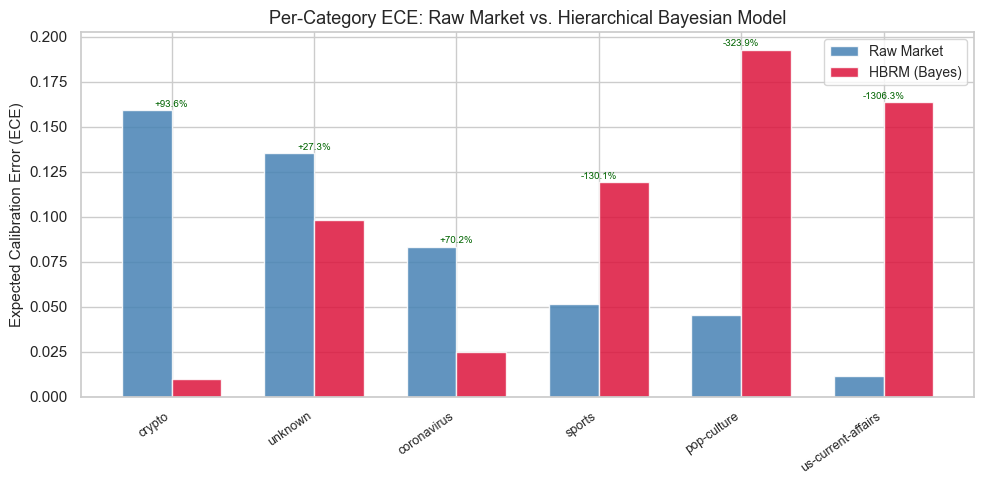

In [4]:
cat_df = per_category_metrics(
    y_test, predictions, df_test["category_str"].astype(str).values
)
print(cat_df.to_string(index=False))
cat_df.to_csv(OUT_DIR / "per_category_metrics.csv", index=False)

fig, ax = plt.subplots(figsize=(max(10, len(cat_df) * 1.2), 5))
cat_df_sorted = cat_df.sort_values("raw_ece", ascending=False)
x = np.arange(len(cat_df_sorted))
w = 0.35
ax.bar(
    x - w / 2,
    cat_df_sorted["raw_ece"],
    w,
    label="Raw Market",
    color="steelblue",
    alpha=0.85,
)
ax.bar(
    x + w / 2,
    cat_df_sorted["hbrm_ece"],
    w,
    label="HBRM (Bayes)",
    color="crimson",
    alpha=0.85,
)
ax.set_xticks(x)
ax.set_xticklabels(cat_df_sorted["category"], rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Expected Calibration Error (ECE)", fontsize=11)
ax.set_title(
    "Per-Category ECE: Raw Market vs. Hierarchical Bayesian Model", fontsize=13
)
ax.legend(fontsize=10)
for i, (_, row) in enumerate(cat_df_sorted.iterrows()):
    ax.text(
        i,
        max(row["raw_ece"], row["hbrm_ece"]) + 0.002,
        f"{row['improvement_pct']:+.1f}%",
        ha="center",
        fontsize=7,
        color="darkgreen",
    )
plt.tight_layout()
plt.savefig(Path(FIGURES_DIR) / "14_per_category_ece.png", dpi=200, bbox_inches="tight")
plt.show()

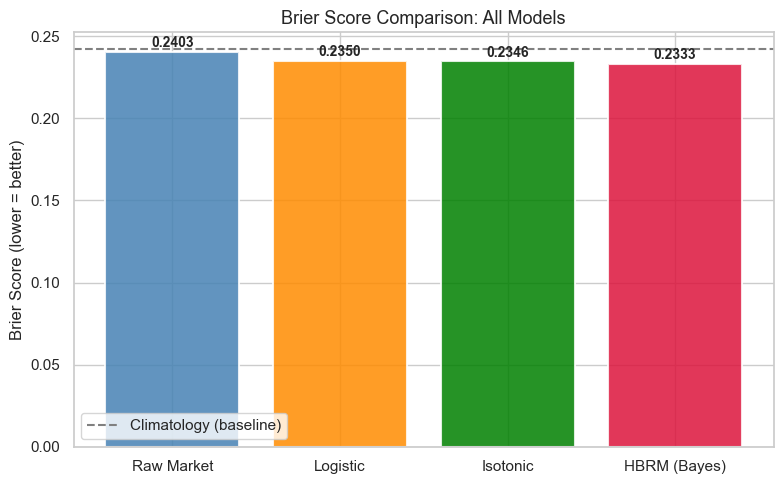

In [5]:
models_eval = ["Raw Market", "Logistic", "Isotonic", "HBRM (Bayes)"]
brier_scores = [brier_score(y_test, predictions[m]) for m in models_eval]
colors_bar = ["steelblue", "darkorange", "green", "crimson"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    models_eval,
    brier_scores,
    color=colors_bar,
    alpha=0.85,
    edgecolor="white",
    linewidth=1.5,
)
clim_line = y_test.mean() * (1 - y_test.mean())
ax.axhline(clim_line, color="gray", linestyle="--", lw=1.5, label="Climatology (baseline)")
for bar, val in zip(bars, brier_scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height() + 0.001,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )
ax.set_ylabel("Brier Score (lower = better)", fontsize=12)
ax.set_title("Brier Score Comparison: All Models", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(Path(FIGURES_DIR) / "15_brier_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

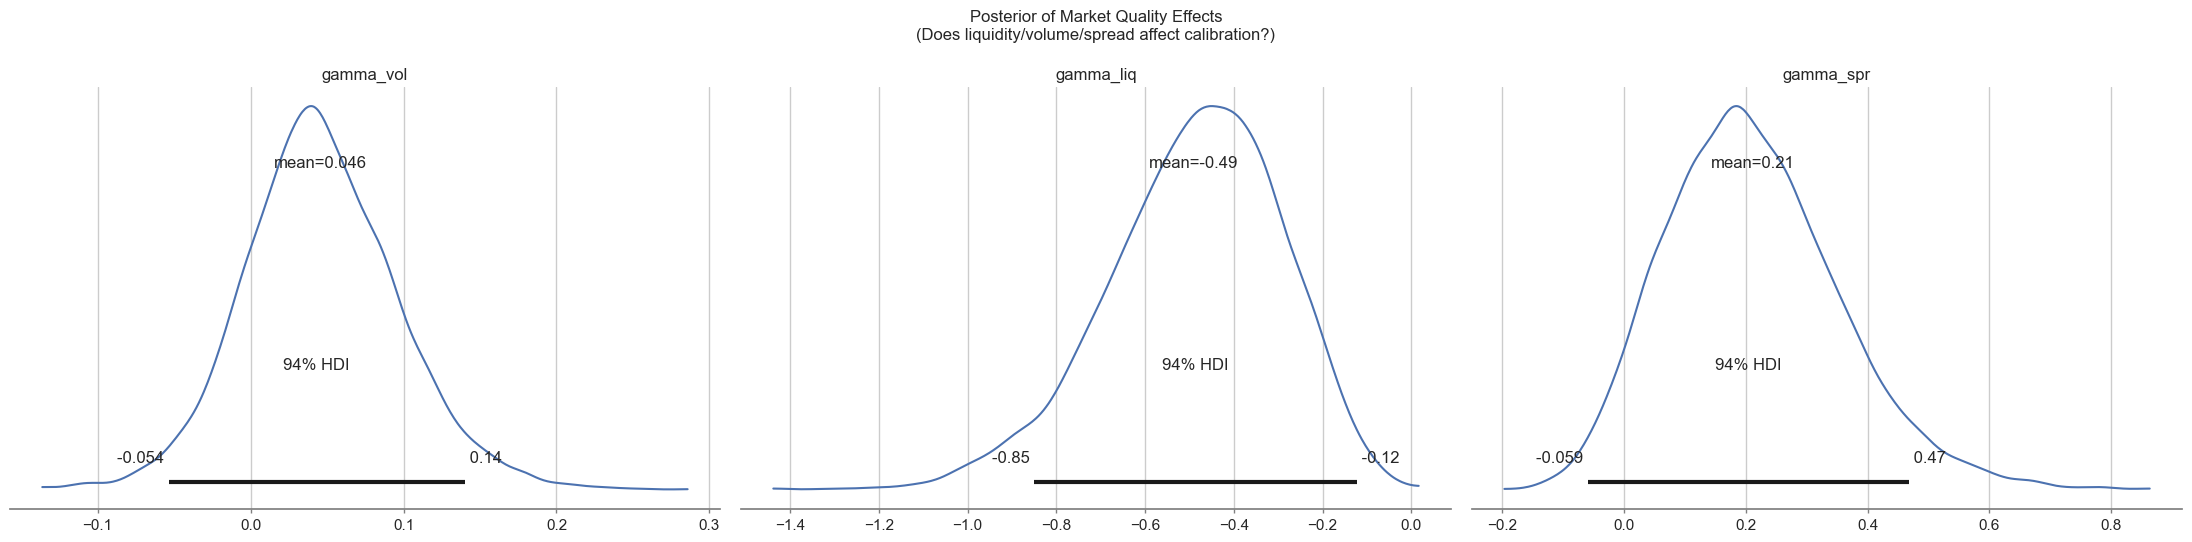

gamma_vol: mean=0.0456, 94% HDI=[-0.0536, 0.1399], P(>0)=0.826
  → No strong evidence of effect (HDI includes 0)
gamma_liq: mean=-0.4903, 94% HDI=[-0.8507, -0.1236], P(>0)=0.000
  → SIGNIFICANT EFFECT (HDI excludes 0)
gamma_spr: mean=0.2110, 94% HDI=[-0.0593, 0.4681], P(>0)=0.946
  → No strong evidence of effect (HDI includes 0)


In [6]:
import arviz as az

trace = az.from_netcdf(Path(POSTERIORS_DIR) / "hbrm_trace.nc")
az.plot_posterior(
    trace, var_names=["gamma_vol", "gamma_liq", "gamma_spr"], hdi_prob=0.94
)
plt.suptitle(
    "Posterior of Market Quality Effects\n(Does liquidity/volume/spread affect calibration?)",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(Path(FIGURES_DIR) / "16_covariate_posteriors.png", dpi=200, bbox_inches="tight")
plt.show()

for var in ["gamma_vol", "gamma_liq", "gamma_spr"]:
    samples = trace.posterior[var].values.flatten()
    hdi = az.hdi(samples, hdi_prob=0.94)
    hdi_lo = float(np.asarray(hdi).flat[0])
    hdi_hi = float(np.asarray(hdi).flat[1])
    prob_positive = (samples > 0).mean()
    print(
        f"{var}: mean={samples.mean():.4f}, 94% HDI=[{hdi_lo:.4f}, {hdi_hi:.4f}], P(>0)={prob_positive:.3f}"
    )
    if hdi_lo > 0 or hdi_hi < 0:
        print("  → SIGNIFICANT EFFECT (HDI excludes 0)")
    else:
        print("  → No strong evidence of effect (HDI includes 0)")